In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [6]:
# Generating synthetic dataset related to Kumbh Mela
np.random.seed(42)
days = np.arange(1, 101)  # 100 days of event
weekend = (days % 7 == 0).astype(int)  # Feature: Is weekend
special_event = ((days % 15 == 0) | (days % 30 == 0)).astype(int)  # Feature: Special event days
tourists = 5000 + 300 * days + 2000 * weekend + 5000 * special_event + np.random.normal(0, 3000, size=len(days))  # Simulated tourist footfall

data = pd.DataFrame({'Days': days, 'Weekend': weekend, 'Special_Event': special_event, 'Tourists': tourists})
data.tail(5)

,Days,Weekend,Special_Event,Tourists
95,96,0,0,29409.455156
96,97,0,0,34988.360831
97,98,1,0,37183.165817
98,99,0,0,34715.340370
99,100,0,0,34296.238600


In [7]:
# Splitting data into train and test sets
X = data[['Days', 'Weekend', 'Special_Event']]
y = data['Tourists']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train

,Days,Weekend,Special_Event
55,56,1,0
88,89,0,0
26,27,0,0
42,43,0,0
69,70,1,0
...,...,...,...
60,61,0,0
71,72,0,0
14,15,0,1
92,93,0,0


In [8]:
# Applying Polynomial Features
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [9]:
# Training a Polynomial Regression model
model = LinearRegression()
model.fit(X_train_poly, y_train)

LinearRegression()

In [10]:
# Making predictions
y_pred = model.predict(X_test_poly)

In [12]:
# Evaluating the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

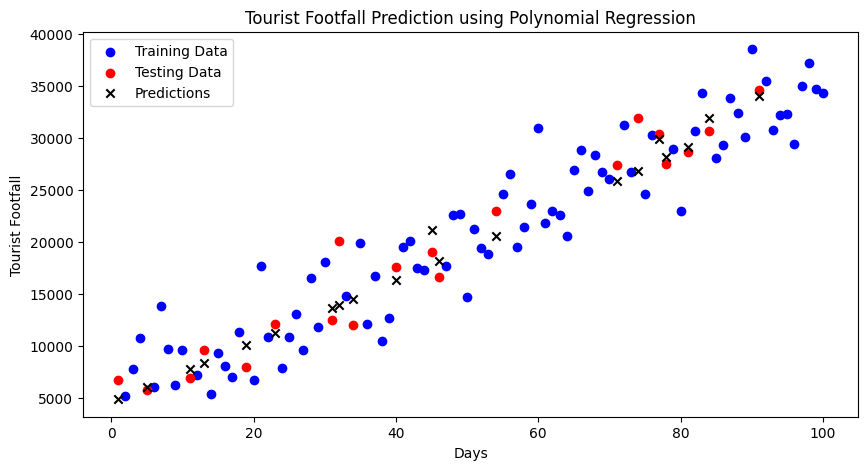

In [13]:
# Plotting results
plt.figure(figsize=(10, 5))
plt.scatter(X_train['Days'], y_train, color='blue', label='Training Data')
plt.scatter(X_test['Days'], y_test, color='red', label='Testing Data')
plt.scatter(X_test['Days'], y_pred, color='black', marker='x', label='Predictions')
plt.xlabel('Days')
plt.ylabel('Tourist Footfall')
plt.title('Tourist Footfall Prediction using Polynomial Regression')
plt.legend()
plt.show()

In [14]:
# Display metrics
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")


Mean Absolute Error: 1714.75
Mean Squared Error: 5089324.92


Improvement Analysis: Before vs. After Feature Engineering & Polynomial Regression

Previous Model (Linear Regression without Feature Engineering)

Mean Absolute Error (MAE): 3006.56

Mean Squared Error (MSE): 15,551,056.06

Updated Model (Polynomial Regression with Feature Engineering)

Mean Absolute Error (MAE): 1714.75  (↓ 42.9% improvement)

Mean Squared Error (MSE): 5,089,324.92 (↓ 67.2% improvement)

Why Did the Model Improve?

* Feature Engineering Added More Context
* We introduced weekend and special event indicators.
*These new features help the model capture real-world variations in tourist footfall (e.g., higher numbers on weekends or festival days).

Polynomial Regression Captures Non-Linear Trends

* The previous linear model assumed a strictly linear relationship between days and tourists.
* Polynomial Regression (degree=2) allows the model to capture curved trends, handling fluctuations better.

Key Takeaways
* Lower MAE → The predictions are, on average, 1,714 tourists off, compared to 3,006 tourists before.
* Lower MSE → The squared errors (which penalize large deviations more) have reduced significantly, meaning better generalization.